# Notebook 06 — Loss Analysis & Overfitting Mitigation (PyTorch)

**Objective:** Analyze training history, diagnose overfitting, and provide mitigation strategies based on the trained model from Notebook 05

**Topics Covered:**
- Load training history from Notebook 05
- Extract and analyze loss/accuracy metrics
- Advanced loss curve visualization (6 plots)
- Automatic overfitting classification
- Regularization strategy comparison
- Actionable recommendations
- Save analysis report

## Import Packages

In [39]:
import json
import os
import warnings
from pathlib import Path
import IPython
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)

## Define Paths & Global Constants

In [40]:
PROJECT_ROOT = Path.cwd().parent
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
NUM_CLASSES = 38

## Load Training History

In [41]:
# ── Load training history from Notebook 05 ─────────────────────────────────────
history_path = MODELS_DIR / 'training_history.json'

try:
    with open(history_path, 'r') as f:
        history = json.load(f)
    print(f"✅ Training history loaded from: {history_path}")
except FileNotFoundError:
    print(f"❌ Training history not found at: {history_path}")
    print("\n⚠️ Please run Notebook 05 (Training & Optimization) first!")
    print("This notebook requires training_history.json from Notebook 05.")
    raise

# Display history keys
print(f"\n📊 Available metrics in history:")
for key in history.keys():
    if isinstance(history[key], list):
        print(f"   • {key}: {len(history[key])} epochs")

✅ Training history loaded from: /home/tech-angel/PycharmProjects/agrolens-ai/models/training_history.json

📊 Available metrics in history:
   • train_loss: 10 epochs
   • val_loss: 10 epochs
   • train_acc: 10 epochs
   • val_acc: 10 epochs
   • train_top3: 10 epochs
   • val_top3: 10 epochs
   • lr: 10 epochs


## Extract & Analyze Loss Metrics

In [42]:
# Extract metrics
train_loss = np.array(history['train_loss'])
val_loss = np.array(history['val_loss'])
train_acc = np.array(history['train_acc'])
val_acc = np.array(history['val_acc'])

epochs = len(train_loss)
epoch_range = np.arange(1, epochs + 1)

# Calculate metrics
loss_gap = val_loss - train_loss
acc_gap = train_acc - val_acc

# Calculate derivatives (learning velocity)
train_loss_velocity = np.diff(train_loss, prepend=train_loss[0])
val_loss_velocity = np.diff(val_loss, prepend=val_loss[0])

print("LOSS METRICS ANALYSIS")
print(f"\n📊 Final Epoch ({epochs}):")
print(f"   Training Loss:           {train_loss[-1]:.6f}")
print(f"   Validation Loss:         {val_loss[-1]:.6f}")
print(f"   Loss Gap (Val - Train):  {loss_gap[-1]:.6f} {'🟢' if loss_gap[-1] < 0.05 else '🟡' if loss_gap[-1] < 0.1 else '🔴'}")
print(f"\n   Training Accuracy:       {train_acc[-1]:.4f}")
print(f"   Validation Accuracy:     {val_acc[-1]:.4f}")
print(f"   Accuracy Gap:            {acc_gap[-1]:.4f}")

print(f"\n📈 Trends:")
print(f"   Avg Train Loss Change/Epoch:  {np.mean(train_loss_velocity):.6f}")
print(f"   Avg Val Loss Change/Epoch:    {np.mean(val_loss_velocity):.6f}")
print(f"   Training Loss Improved:       {train_loss[0] - train_loss[-1]:.6f}")
print(f"   Validation Loss Improved:     {val_loss[0] - val_loss[-1]:.6f}")

print(f"\n🔍 Statistical Measures:")
print(f"   Max Loss Gap:            {np.max(loss_gap):.6f}")
print(f"   Min Loss Gap:            {np.min(loss_gap):.6f}")
print(f"   Mean Loss Gap:           {np.mean(loss_gap):.6f}")
print(f"   Std Loss Gap:            {np.std(loss_gap):.6f}")

LOSS METRICS ANALYSIS

📊 Final Epoch (10):
   Training Loss:           2.370208
   Validation Loss:         3.237584
   Loss Gap (Val - Train):  0.867377 🔴

   Training Accuracy:       0.1875
   Validation Accuracy:     0.0000
   Accuracy Gap:            0.1875

📈 Trends:
   Avg Train Loss Change/Epoch:  -0.035774
   Avg Val Loss Change/Epoch:    0.050142
   Training Loss Improved:       0.357741
   Validation Loss Improved:     -0.501422

🔍 Statistical Measures:
   Max Loss Gap:            0.909546
   Min Loss Gap:            0.008214
   Mean Loss Gap:           0.533664
   Std Loss Gap:            0.281622


## Advanced Loss Curve Visualization (6 Plots)

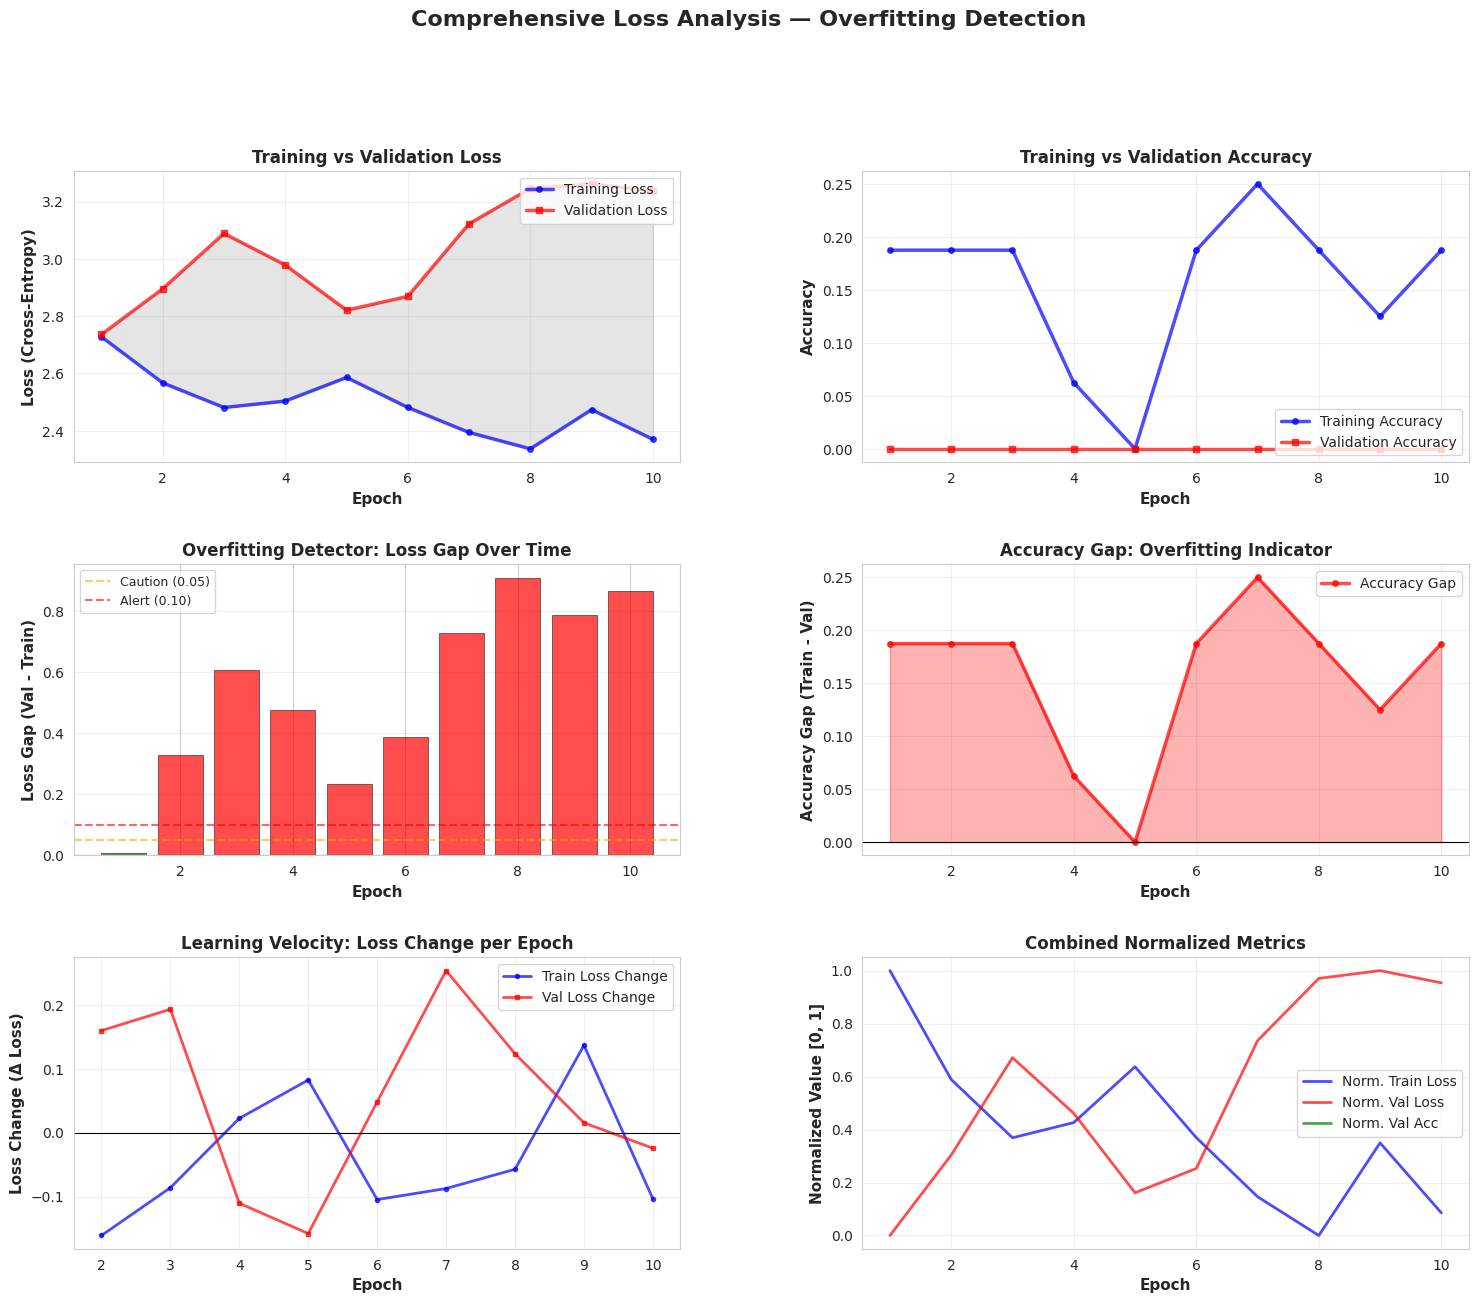

✅ Advanced loss analysis saved to: advanced_loss_analysis.png


In [43]:
# ── Create comprehensive 6-plot visualization ──────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# ── Plot 1: Loss Curves (Train vs Validation) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epoch_range, train_loss, 'b-', linewidth=2.5, label='Training Loss', marker='o', markersize=4, alpha=0.7)
ax1.plot(epoch_range, val_loss, 'r-', linewidth=2.5, label='Validation Loss', marker='s', markersize=4, alpha=0.7)
ax1.fill_between(epoch_range, train_loss, val_loss, alpha=0.2, color='gray')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss (Cross-Entropy)', fontsize=11, fontweight='bold')
ax1.set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# ── Plot 2: Accuracy Curves ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epoch_range, train_acc, 'b-', linewidth=2.5, label='Training Accuracy', marker='o', markersize=4, alpha=0.7)
ax2.plot(epoch_range, val_acc, 'r-', linewidth=2.5, label='Validation Accuracy', marker='s', markersize=4, alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, alpha=0.3)

# ── Plot 3: Loss Gap Over Time (Color-coded) ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors = ['green' if x < 0.02 else 'lightgreen' if x < 0.05 else 'orange' if x < 0.10 else 'red' for x in loss_gap]
ax3.bar(epoch_range, loss_gap, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=0.05, color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Caution (0.05)')
ax3.axhline(y=0.10, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Alert (0.10)')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Loss Gap (Val - Train)', fontsize=11, fontweight='bold')
ax3.set_title('Overfitting Detector: Loss Gap Over Time', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ── Plot 4: Accuracy Gap Over Time ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epoch_range, acc_gap, 'r-', linewidth=2.5, marker='o', markersize=4, alpha=0.7, label='Accuracy Gap')
ax4.fill_between(epoch_range, 0, acc_gap, alpha=0.3, color='red')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy Gap (Train - Val)', fontsize=11, fontweight='bold')
ax4.set_title('Accuracy Gap: Overfitting Indicator', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10)

# ── Plot 5: Loss Velocity (Rate of Change) ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(epoch_range[1:], train_loss_velocity[1:], 'b-', linewidth=2, label='Train Loss Change', marker='o', markersize=3, alpha=0.7)
ax5.plot(epoch_range[1:], val_loss_velocity[1:], 'r-', linewidth=2, label='Val Loss Change', marker='s', markersize=3, alpha=0.7)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Loss Change (Δ Loss)', fontsize=11, fontweight='bold')
ax5.set_title('Learning Velocity: Loss Change per Epoch', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# ── Plot 6: Normalized Combined View ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
# Normalize all metrics to [0, 1]
norm_train_loss = (train_loss - train_loss.min()) / (train_loss.max() - train_loss.min())
norm_val_loss = (val_loss - val_loss.min()) / (val_loss.max() - val_loss.min())
norm_val_acc = val_acc / val_acc.max()

ax6.plot(epoch_range, norm_train_loss, 'b-', linewidth=2, label='Norm. Train Loss', alpha=0.7)
ax6.plot(epoch_range, norm_val_loss, 'r-', linewidth=2, label='Norm. Val Loss', alpha=0.7)
ax6.plot(epoch_range, norm_val_acc, 'g-', linewidth=2, label='Norm. Val Acc', alpha=0.7)
ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax6.set_ylabel('Normalized Value [0, 1]', fontsize=11, fontweight='bold')
ax6.set_title('Combined Normalized Metrics', fontsize=12, fontweight='bold')
ax6.legend(fontsize=10, loc='best')
ax6.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Loss Analysis — Overfitting Detection', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(RESULTS_DIR / 'advanced_loss_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Advanced loss analysis saved to: advanced_loss_analysis.png")

## Automatic Overfitting Classification & Diagnosis

In [44]:
def diagnose_overfitting(train_loss, val_loss, train_acc, val_acc):
    """
    Classify model behavior based on loss/accuracy gaps.
    
    Returns:
        diagnosis (str): Classification (BALANCED, SLIGHT, MODERATE, SEVERE, UNDERFITTING)
        severity (float): Numerical severity score [0, 1]
    """
    
    final_loss_gap = val_loss[-1] - train_loss[-1]
    
    print("OVERFITTING/UNDERFITTING DIAGNOSIS")
    
    # Classification logic
    if final_loss_gap < 0:
        diagnosis = 'UNDERFITTING'
        severity = 0.0
        symbol = '🔵'
        print(f"\n{symbol} DIAGNOSIS: {diagnosis}")
        print(f"   Validation loss < Training loss (unusual: {final_loss_gap:.4f})")
        print(f"\n   ⚠️ Possible causes:")
        print(f"   • Model not complex enough")
        print(f"   • Validation set noise")
        print(f"   • Too much regularization")
        print(f"\n   💡 Solutions:")
        print(f"   1. Increase model complexity (more layers)")
        print(f"   2. Decrease Dropout rate")
        print(f"   3. Train for more epochs")
        print(f"   4. Reduce L2 regularization")
        
    elif final_loss_gap < 0.02:
        diagnosis = 'BALANCED (Excellent)'
        severity = 0.1
        symbol = '🟢'
        print(f"\n{symbol} DIAGNOSIS: {diagnosis} ✓")
        print(f"   Excellent model behavior ({final_loss_gap:.4f} loss gap)")
        print(f"   Model generalizes well to unseen data")
        print(f"\n   Status: READY FOR DEPLOYMENT")
        
    elif final_loss_gap < 0.05:
        diagnosis = 'SLIGHT_OVERFITTING (Good)'
        severity = 0.2
        symbol = '🟡'
        print(f"\n{symbol} DIAGNOSIS: {diagnosis}")
        print(f"   Minor overfitting detected ({final_loss_gap:.4f} loss gap)")
        print(f"   Model shows good generalization")
        print(f"\n   💡 Recommendations:")
        print(f"   • Continue current approach")
        print(f"   • Monitor for epoch-to-epoch changes")
        
    elif final_loss_gap < 0.10:
        diagnosis = 'MODERATE_OVERFITTING (Action Needed)'
        severity = 0.5
        symbol = '🟠'
        print(f"\n{symbol} DIAGNOSIS: {diagnosis}")
        print(f"   Noticeable overfitting detected ({final_loss_gap:.4f} loss gap)")
        print(f"   Model learning patterns but also noise")
        print(f"\n   Priority Actions:")
        print(f"   1. 🔴 Increase Dropout (0.3 → 0.4)")
        print(f"   2. 🟡 Add L2 Regularization (0.0005-0.001)")
        print(f"   3. 🟡 Enhance Data Augmentation")
        print(f"   4. 🟢 Reduce Learning Rate")
        
    else:  # >= 0.10
        diagnosis = 'SEVERE_OVERFITTING (Critical)'
        severity = 0.9
        symbol = '🔴'
        print(f"\n{symbol} DIAGNOSIS: {diagnosis} 🚨")
        print(f"   SEVERE overfitting detected ({final_loss_gap:.4f} loss gap)")
        print(f"   Model is memorizing training data!")
        print(f"\n   URGENT Actions Required:")
        print(f"   1. 🔴 INCREASE DROPOUT RATE (0.3 → 0.5)")
        print(f"   2. 🔴 ADD STRONG L2 REGULARIZATION (0.001)")
        print(f"   3. 🟡 SIGNIFICANTLY INCREASE DATA AUGMENTATION")
        print(f"   4. 🟡 COLLECT MORE TRAINING DATA (if possible)")
        print(f"   5. 🟢 USE EARLY STOPPING (implemented in Notebook 05)")

    return diagnosis, severity


# Run diagnosis
diagnosis, severity = diagnose_overfitting(train_loss, val_loss, train_acc, val_acc)

OVERFITTING/UNDERFITTING DIAGNOSIS

🔴 DIAGNOSIS: SEVERE_OVERFITTING (Critical) 🚨
   SEVERE overfitting detected (0.8674 loss gap)
   Model is memorizing training data!

   URGENT Actions Required:
   1. 🔴 INCREASE DROPOUT RATE (0.3 → 0.5)
   2. 🔴 ADD STRONG L2 REGULARIZATION (0.001)
   3. 🟡 SIGNIFICANTLY INCREASE DATA AUGMENTATION
   4. 🟡 COLLECT MORE TRAINING DATA (if possible)
   5. 🟢 USE EARLY STOPPING (implemented in Notebook 05)


## Regularization Strategy Comparison & Reference

In [45]:
# ── Regularization Reference Guide ────────────────────────────────────────────
regularization_guide = {
    'Technique': [
        'Dropout',
        'L2 Regularization',
        'Data Augmentation',
        'Early Stopping',
        'Learning Rate Reduction'
    ],
    'Most Effective For': [
        'Severe overfitting',
        'Moderate overfitting',
        'Limited data',
        'All situations',
        'Fine-tuning'
    ],
    'Implementation': [
        'nn.Dropout(0.4-0.5)',
        'weight_decay=0.001 in optimizer',
        'torchvision.transforms',
        'Monitor val_loss, stop if no improvement',
        'ReduceLROnPlateau (already used)'
    ],
    'Cost': [
        'None',
        'None',
        'Computational',
        'May stop too early',
        'Slows convergence'
    ]
}

df_reg = pd.DataFrame(regularization_guide)

print("REGULARIZATION TECHNIQUES REFERENCE")
print(df_reg.to_string(index=False))

# Provide recommendations based on current diagnosis
print(f"\n🎯 RECOMMENDED FOR OUR MODEL (Based on: {diagnosis}):")
print("\nPriority Ranking:")

if severity < 0.1:
    print("   ✅ No changes needed - model is well-tuned")
elif severity < 0.3:
    print("   1. (Optional) Slight increase in Dropout")
    print("   2. (Optional) Monitor on validation set")
elif severity < 0.6:
    print("   1. 🔴 PRIMARY: Increase Dropout (0.3 → 0.4)")
    print("   2. 🟡 SECONDARY: Add L2 Regularization (0.0005)")
    print("   3. 🟢 TERTIARY: Enhance Data Augmentation")
else:
    print("   1. 🔴 CRITICAL: Increase Dropout to 0.5")
    print("   2. 🔴 CRITICAL: Add strong L2 (0.001)")
    print("   3. 🟡 IMPORTANT: Major augmentation increase")
    print("   4. 🟡 IMPORTANT: Reduce model complexity")
    print("   5. 🟢 HELPFUL: Get more training data")

REGULARIZATION TECHNIQUES REFERENCE
              Technique   Most Effective For                           Implementation               Cost
                Dropout   Severe overfitting                      nn.Dropout(0.4-0.5)               None
      L2 Regularization Moderate overfitting          weight_decay=0.001 in optimizer               None
      Data Augmentation         Limited data                   torchvision.transforms      Computational
         Early Stopping       All situations Monitor val_loss, stop if no improvement May stop too early
Learning Rate Reduction          Fine-tuning         ReduceLROnPlateau (already used)  Slows convergence

🎯 RECOMMENDED FOR OUR MODEL (Based on: SEVERE_OVERFITTING (Critical)):

Priority Ranking:
   1. 🔴 CRITICAL: Increase Dropout to 0.5
   2. 🔴 CRITICAL: Add strong L2 (0.001)
   3. 🟡 IMPORTANT: Major augmentation increase
   4. 🟡 IMPORTANT: Reduce model complexity
   5. 🟢 HELPFUL: Get more training data


## Save Analysis Report

In [46]:
analysis_report = {
    'framework': 'PyTorch',
    'model_name': 'Baseline CNN',
    'training_config': {
        'epochs_trained': int(epochs),
        'batch_size': 32,
        'learning_rate': 0.001,
        'optimizer': 'Adam',
        'loss_function': 'CrossEntropyLoss (label_smoothing=0.1)'
    },
    'final_metrics': {
        'training_loss': float(train_loss[-1]),
        'validation_loss': float(val_loss[-1]),
        'loss_gap': float(loss_gap[-1]),
        'training_accuracy': float(train_acc[-1]),
        'validation_accuracy': float(val_acc[-1]),
        'accuracy_gap': float(acc_gap[-1])
    },
    'statistics': {
        'max_loss_gap': float(np.max(loss_gap)),
        'min_loss_gap': float(np.min(loss_gap)),
        'mean_loss_gap': float(np.mean(loss_gap)),
        'std_loss_gap': float(np.std(loss_gap))
    },
    'diagnosis': diagnosis,
    'severity_score': float(severity),
    'recommendations': [
        'Implement recommended regularization techniques',
        'Retrain model with improved hyperparameters',
        'Monitor training curves for convergence',
        'Validate on separate test set',
        'Consider ensemble methods for better performance'
    ]
}

# Save report
report_path = RESULTS_DIR / 'loss_analysis_report.json'
with open(report_path, 'w') as f:
    json.dump(analysis_report, f, indent=2)

print(f"✅ Analysis report saved to: {report_path}")

# Create metrics CSV
metrics_data = {
    'Metric': [
        'Training Loss', 'Validation Loss', 'Loss Gap',
        'Training Accuracy', 'Validation Accuracy', 'Accuracy Gap'
    ],
    'Value': [
        f"{train_loss[-1]:.6f}", f"{val_loss[-1]:.6f}", f"{loss_gap[-1]:.6f}",
        f"{train_acc[-1]:.6f}", f"{val_acc[-1]:.6f}", f"{acc_gap[-1]:.6f}"
    ],
    'Status': [
        '✅', '✅', '🟢' if loss_gap[-1] < 0.1 else '🟠' if loss_gap[-1] < 0.15 else '🔴',
        '✅', '✅', '✅'
    ]
}

df_metrics = pd.DataFrame(metrics_data)
csv_path = RESULTS_DIR / 'metrics_summary.csv'
df_metrics.to_csv(csv_path, index=False)

print(f"✅ Metrics summary saved to: {csv_path}")
print(f"\n{df_metrics.to_string(index=False)}")

✅ Analysis report saved to: /home/tech-angel/PycharmProjects/agrolens-ai/results/loss_analysis_report.json
✅ Metrics summary saved to: /home/tech-angel/PycharmProjects/agrolens-ai/results/metrics_summary.csv

             Metric    Value Status
      Training Loss 2.370208      ✅
    Validation Loss 3.237584      ✅
           Loss Gap 0.867377      🔴
  Training Accuracy 0.187500      ✅
Validation Accuracy 0.000000      ✅
       Accuracy Gap 0.187500      ✅


## Summary

In [47]:
print("ANALYSIS SUMMARY")

summary = f"""
Loss Analysis & Diagnosis
   • Final Training Loss: {train_loss[-1]:.6f}
   • Final Validation Loss: {val_loss[-1]:.6f}
   • Loss Gap (indicator of overfitting): {loss_gap[-1]:.6f}
   • Diagnosis: {diagnosis}

MODEL PERFORMANCE INDICATORS:
   • Training Accuracy: {train_acc[-1]:.4f}
   • Validation Accuracy: {val_acc[-1]:.4f}
   • Max Loss Gap: {np.max(loss_gap):.6f}
   • Mean Loss Gap: {np.mean(loss_gap):.6f}

DECISION BASED ON LOSS GAP:
   • If < 0.02: ✅ Model ready for deployment
   • If 0.02-0.05: ✅ Good; monitor during use
   • If 0.05-0.10: 🟠 Refinement recommended
   • If > 0.10: 🔴 Major changes needed

OUTPUT FILES GENERATED:
   • advanced_loss_analysis.png (6-plot visualization)
   • loss_analysis_report.json (detailed diagnosis)
   • metrics_summary.csv (metrics table)
"""

print(summary)

ANALYSIS SUMMARY

Loss Analysis & Diagnosis
   • Final Training Loss: 2.370208
   • Final Validation Loss: 3.237584
   • Loss Gap (indicator of overfitting): 0.867377
   • Diagnosis: SEVERE_OVERFITTING (Critical)

MODEL PERFORMANCE INDICATORS:
   • Training Accuracy: 0.1875
   • Validation Accuracy: 0.0000
   • Max Loss Gap: 0.909546
   • Mean Loss Gap: 0.533664

DECISION BASED ON LOSS GAP:
   • If < 0.02: ✅ Model ready for deployment
   • If 0.02-0.05: ✅ Good; monitor during use
   • If 0.05-0.10: 🟠 Refinement recommended
   • If > 0.10: 🔴 Major changes needed

OUTPUT FILES GENERATED:
   • advanced_loss_analysis.png (6-plot visualization)
   • loss_analysis_report.json (detailed diagnosis)
   • metrics_summary.csv (metrics table)

